/tmp/ipykernel_803/1296325645.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_mpg, x='cylinders', y='mpg', palette='Blues', ax=axes[1, 0])
/tmp/ipykernel_803/1296325645.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_mpg_origin, x='origin', y='mpg', palette='autumn', ax=axes[1, 1])


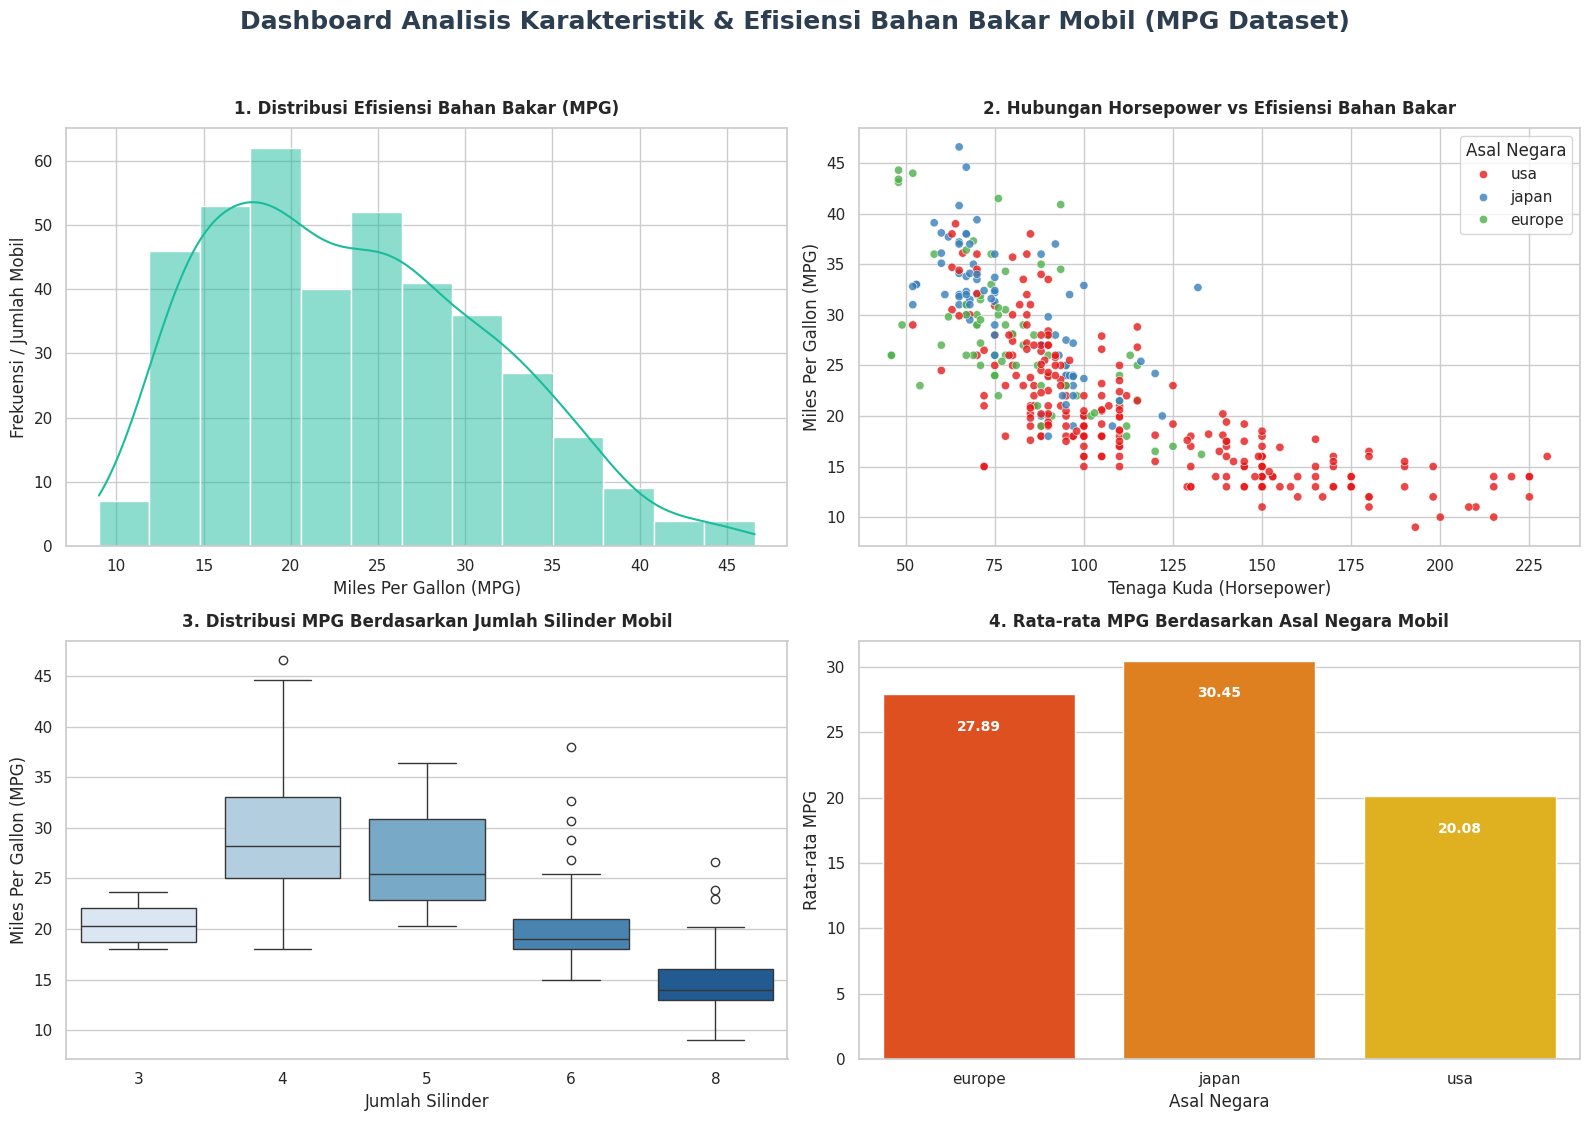

In [3]:
# ==============================================================================
# TUGAS BAB 6: DASHBOARD VISUALISASI STATIS UTUH
# Mata Kuliah: Pengantar Data Science - Pertemuan 7
# ==============================================================================

# LANGKAH 1: Mengimpor Library yang Diperlukan
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# LANGKAH 2: Mengatur Tema Dasar Visualisasi (Agar Tampilan Estetis)
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

# LANGKAH 3: Memuat Dataset (Menggunakan Dataset 'mpg' sesuai rekomendasi modul)
# Dataset 'mpg' berisi data konsumsi bahan bakar, silinder, horsepower, asal negara mobil, dll.
data_mpg = sns.load_dataset('mpg')

# Membersihkan data missing value singkat pada kolom horsepower agar grafik rapi
data_mpg['horsepower'] = data_mpg['horsepower'].fillna(data_mpg['horsepower'].median())

# ==============================================================================
# LANGKAH 4: Inisialisasi Arsitektur Dashboard (Grid 2x2 = 4 Grafik)
# ==============================================================================
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

# Berikan Judul Utama untuk Dashboard Visualisasi
fig.suptitle('Dashboard Analisis Karakteristik & Efisiensi Bahan Bakar Mobil (MPG Dataset)',
             fontsize=18, fontweight='bold', y=0.96, color='#2c3e50')

# ------------------------------------------------------------------------------
# GRAFIK 1 (Kiri Atas): Histogram & KDE - Distribusi Fitur Tunggal (MPG)
# ------------------------------------------------------------------------------
sns.histplot(data=data_mpg, x='mpg', kde=True, color='#1abc9c', ax=axes[0, 0])
axes[0, 0].set_title('1. Distribusi Efisiensi Bahan Bakar (MPG)', fontsize=12, fontweight='bold', pad=10)
axes[0, 0].set_xlabel('Miles Per Gallon (MPG)')
axes[0, 0].set_ylabel('Frekuensi / Jumlah Mobil')

# ------------------------------------------------------------------------------
# GRAFIK 2 (Kanan Atas): Scatter Plot - Hubungan Dua Variabel (Horsepower vs MPG)
# ------------------------------------------------------------------------------
sns.scatterplot(data=data_mpg, x='horsepower', y='mpg', hue='origin', palette='Set1', alpha=0.8, ax=axes[0, 1])
axes[0, 1].set_title('2. Hubungan Horsepower vs Efisiensi Bahan Bakar', fontsize=12, fontweight='bold', pad=10)
axes[0, 1].set_xlabel('Tenaga Kuda (Horsepower)')
axes[0, 1].set_ylabel('Miles Per Gallon (MPG)')
axes[0, 1].legend(title='Asal Negara')

# ------------------------------------------------------------------------------
# GRAFIK 3 (Kiri Bawah): Boxplot - Distribusi per Kelompok (MPG Berdasarkan Jumlah Silinder)
# ------------------------------------------------------------------------------
sns.boxplot(data=data_mpg, x='cylinders', y='mpg', palette='Blues', ax=axes[1, 0])
axes[1, 0].set_title('3. Distribusi MPG Berdasarkan Jumlah Silinder Mobil', fontsize=12, fontweight='bold', pad=10)
axes[1, 0].set_xlabel('Jumlah Silinder')
axes[1, 0].set_ylabel('Miles Per Gallon (MPG)')

# ------------------------------------------------------------------------------
# GRAFIK 4 (Kanan Bawah): Bar Chart - Perbandingan Antar Kategori (Rata-rata MPG per Negara)
# ------------------------------------------------------------------------------
# Menghitung rata-rata MPG per negara asal terlebih dahulu
avg_mpg_origin = data_mpg.groupby('origin')['mpg'].mean().reset_index()

sns.barplot(data=avg_mpg_origin, x='origin', y='mpg', palette='autumn', ax=axes[1, 1])
axes[1, 1].set_title('4. Rata-rata MPG Berdasarkan Asal Negara Mobil', fontsize=12, fontweight='bold', pad=10)
axes[1, 1].set_xlabel('Asal Negara')
axes[1, 1].set_ylabel('Rata-rata MPG')

# Menambahkan label nilai di atas balok batang (Bar) agar chart informatif
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{p.get_height():.2f}",
                        (p.get_x() + p.get_width() / 2., p.get_height() - 3),
                        ha='center', va='center',
                        xytext=(0, 5),
                        textcoords='offset points',
                        fontsize=10, fontweight='bold', color='white')

# ==============================================================================
# LANGKAH 5: Sentuhan Akhir Tata Letak (Anatomi Chart yang Baik)
# ==============================================================================
# Mengatur jarak antar grafik otomatis agar teks tidak saling tumpang tindih
plt.tight_layout(rect=[0, 0.03, 1, 0.93])

# Menampilkan Dashboard secara Utuh
plt.show()